Adding the necessary libraries

In [2]:
#!/usr/bin/env python3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

Loading video game sales data from github to a dataframe

In [3]:
url = "https://gist.githubusercontent.com/designernatan/27da044c6dc823f7ac7fe3a01f4513ed/raw/d15b5c7d7a5efb38750b16ec935fc126ec9a6e79/vgsales.csv"

videoGameData_df = pd.read_csv(url)

pd.set_option('display.width', None)
display(videoGameData_df.head(10))

#videoGameData_df.to_csv('videoGameData.csv')      #saving video game data to a csv as backup

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


Exploratory Data Analysis

Looking at video games by platform

,Platform,count
0,DS,2163
1,PS2,2161
2,PS3,1329
3,Wii,1325
4,X360,1265
5,PSP,1213
6,PS,1196
7,PC,960
8,XB,824
9,GBA,822


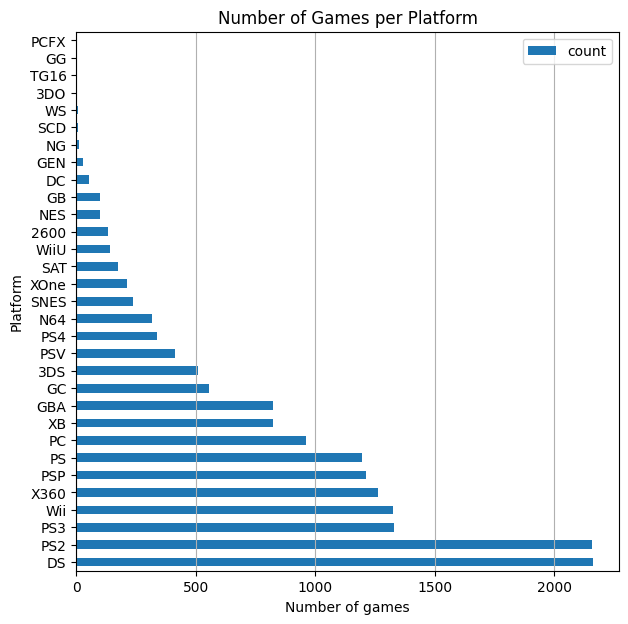

In [42]:
df = videoGameData_df['Platform'].value_counts().reset_index()
#df = df.to_frame()
display(df)
#print(df.columns.tolist())

df.plot(x='Platform', y='count', kind='barh', figsize=[7,7])
#plt.xticks(rotation=0, ha='right')
plt.xlabel(xlabel='Number of games')
plt.title('Number of Games per Platform')
plt.grid(axis='x')
plt.show()

Looking at Game genre distribution overall

           Genre  count
0         Action   3316
1         Sports   2346
2           Misc   1739
3   Role-Playing   1488
4        Shooter   1310
5      Adventure   1286
6         Racing   1249
7       Platform    886
8     Simulation    867
9       Fighting    848
10      Strategy    681
11        Puzzle    582


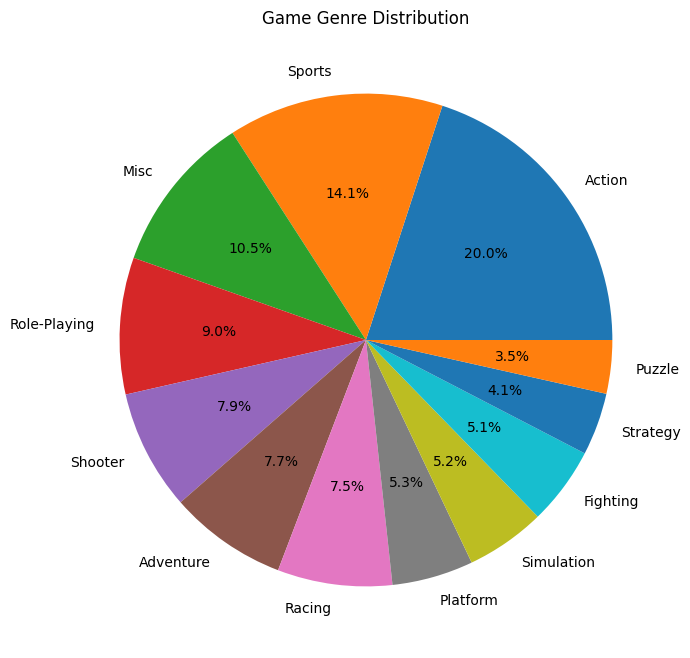

In [58]:
df = videoGameData_df['Genre'].value_counts().reset_index()
print(df)

df.plot(y='count', kind='pie', labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10}, figsize=(12,8), legend=False)
plt.ylabel('')
plt.title('Game Genre Distribution')
plt.show()

Looking at the platforms with the most and least games released

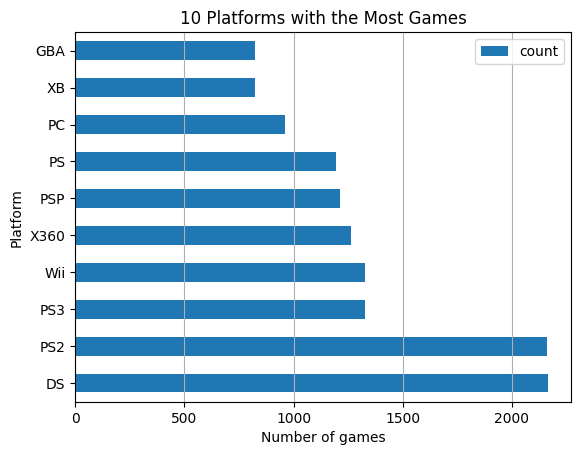

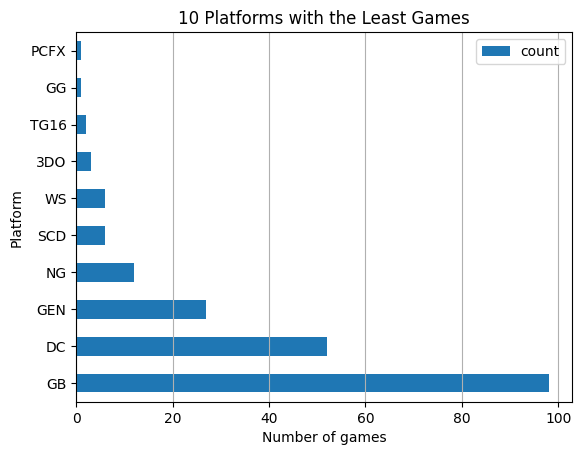

In [6]:
df = videoGameData_df['Platform'].value_counts().reset_index()

dfMost = df.head(10)
dfMost.plot(x='Platform', y='count', kind='barh')
#plt.xticks(rotation=0, ha='right')
plt.xlabel(xlabel='Number of games')
plt.title('10 Platforms with the Most Games')
plt.grid(axis='x')
plt.show()

dfLeast = df.tail(10)
dfLeast.plot(x='Platform', y='count', kind='barh')
#plt.xticks(rotation=0, ha='right')
plt.xlabel(xlabel='Number of games')
plt.title('10 Platforms with the Least Games')
plt.grid(axis='x')
plt.show()

Looking at video game genres for top 3 most popular platforms

DS PS2 PS3


Text(0.5, 1.0, 'PS3 Game Genres')

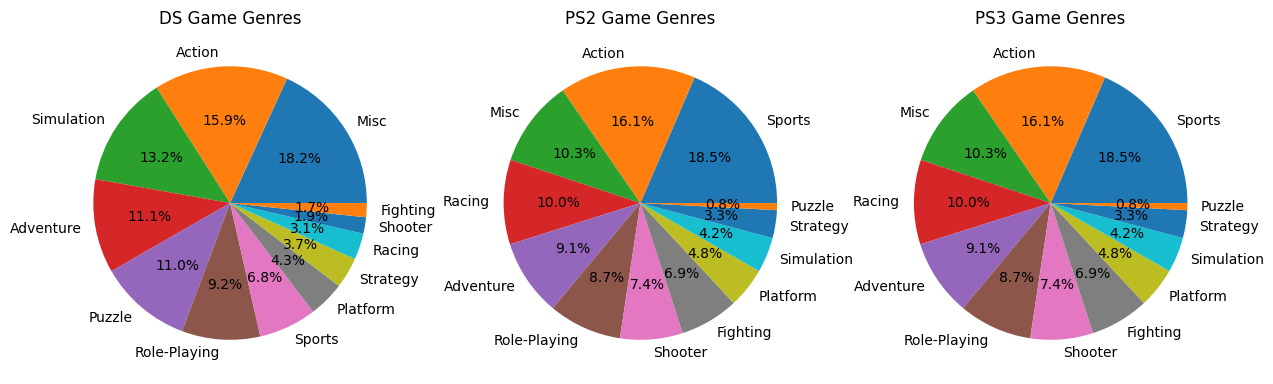

In [ ]:
#df = videoGameData_df['Platform'].value_counts().reset_index()

df = videoGameData_df['Platform'].value_counts().reset_index()
platform1 = df['Platform'][0]   #getting name of platform with most games
platform2 = df['Platform'][1]   #getting name of platform with most games
platform3 = df['Platform'][2]   #getting name of platform with most games
print(platform1, platform2, platform3)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

df = videoGameData_df[videoGameData_df['Platform']==platform1]['Genre'].value_counts().reset_index()
ax1.pie(df['count'], labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10})
ax1.set_title(platform1 + ' Game Genres')

df = videoGameData_df[videoGameData_df['Platform']==platform2]['Genre'].value_counts().reset_index()
ax2.pie(df['count'], labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.set_title(platform2 + ' Game Genres')

df = videoGameData_df[videoGameData_df['Platform']==platform2]['Genre'].value_counts().reset_index()
ax3.pie(df['count'], labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10})
ax3.set_title(platform3 + ' Game Genres')

Sales Trends per Year

Text(0, 0.5, 'Number of Games Sold')

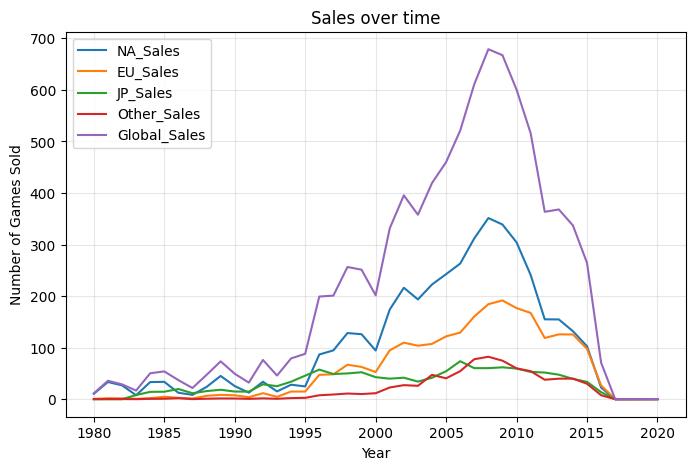

In [ ]:
df = videoGameData_df.groupby('Year').sum().reset_index()
#print(df.head(10))
#print(df.dtypes)

#fig, ax = plt.subplots(figsize=(8, 5))

fig, ax = plt.subplots(figsize=(8, 5))

#ax.plot(df['Platform'], df['NA_Sales'])
ax.plot(df['Year'], df['NA_Sales'], label='NA_Sales')
ax.plot(df['Year'], df['EU_Sales'], label='EU_Sales')
ax.plot(df['Year'], df['JP_Sales'], label='JP_Sales')
ax.plot(df['Year'], df['Other_Sales'], label='Other_Sales')
ax.plot(df['Year'], df['Global_Sales'], label='Global_Sales')

ax.legend(loc='upper left')
ax.set_title('Sales over time')
ax.grid(alpha = 0.3)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Games Sold')

Money per platform bar charts

"ax.bar(df['Platform'], df['NA_Sales'], label='NA_Sales')\nax.bar(df['Platform'], df['EU_Sales'], label='EU_Sales')\nax.bar(df['Platform'], df['JP_Sales'], label='JP_Sales')\nax.bar(df['Platform'], df['Other_Sales'], label='Other_Sales')\nax.bar(df['Platform'], df['Global_Sales'], label='Global_Sales')"

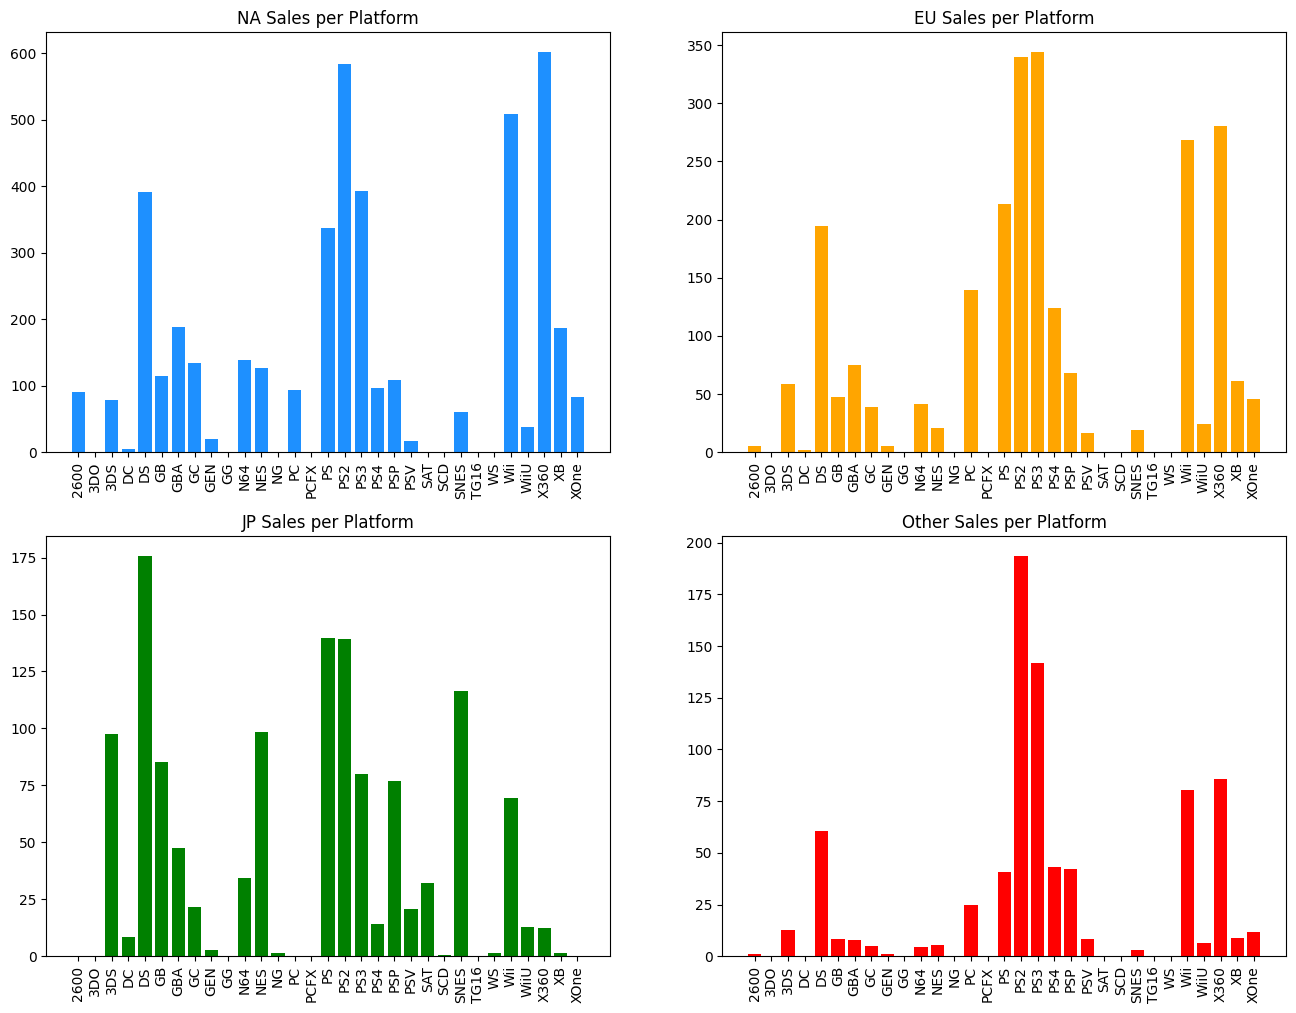

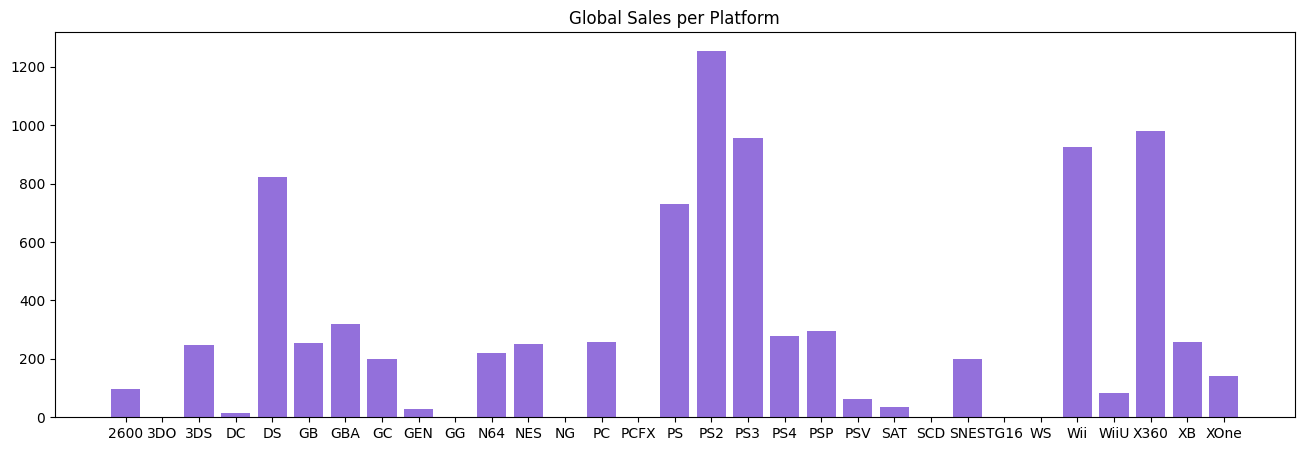

In [ ]:
df = videoGameData_df.groupby('Platform').sum().reset_index()
#display(df.head(10))

fig, ax = plt.subplots(2, 2,figsize=(16, 12))

#print(len(df['Platform']))

ax[0,0].bar(df['Platform'], df['NA_Sales'], label='NA_Sales', color='dodgerblue',)
ax[0,0].set_title('NA Sales per Platform')
ax[0,1].bar(df['Platform'], df['EU_Sales'], label='EU_Sales', color='orange')
ax[0,1].set_title('EU Sales per Platform')
ax[1,0].bar(df['Platform'], df['JP_Sales'], label='JP_Sales', color='green')
ax[1,0].set_title('JP Sales per Platform')
ax[1,1].bar(df['Platform'], df['Other_Sales'], label='Other_Sales', color='red')
ax[1,1].set_title('Other Sales per Platform')

for axs in ax.flatten():
    #axs.tick_params(axis='x', labelsize=8)
    axs.tick_params(axis='x', rotation= 90)

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(df['Platform'], df['Global_Sales'], label='Global_Sales', color='mediumpurple')
ax.set_title('Global Sales per Platform')

Money per platform grouped bar chart

"y = np.arange(len(df['Platform']))  \nheight = 1/5  \n\nfig, ax = plt.subplots(figsize=(5, 15))\n\nax.barh(y - 2*height, df['NA_Sales'], height, label='NA_Sales')\nax.barh(y - height, df['EU_Sales'], height, label='EU_Sales')\nax.barh(y, df['JP_Sales'], height, label='JP_Sales')\nax.barh(y + height, df['Other_Sales'], height, label='Other_Sales')\nax.barh(y + 2*height, df['Global_Sales'], height, label='Global_Sales')\n\nax.legend(loc='upper right')\nax.set_title('Sales per Platform')\nax.grid(alpha = 0.3)\nax.set_ylabel('Platform')\nax.set_xlabel('Number of Games Sold')\nax.set_yticks(y)\nax.set_yticklabels(df['Platform'])"

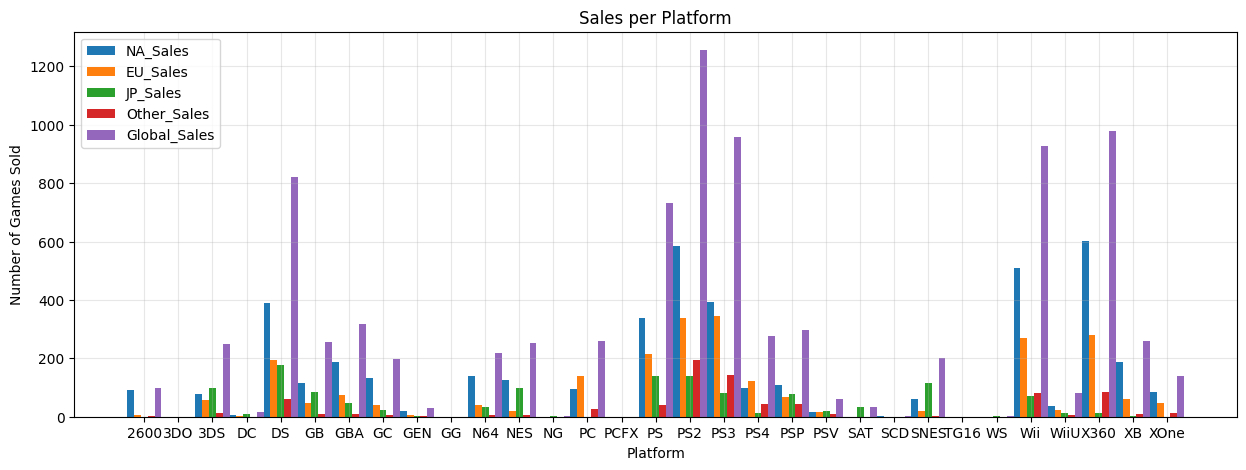

In [ ]:
df = videoGameData_df.groupby('Platform').sum().reset_index()

x = np.arange(len(df['Platform']))  
width = 1/5  

fig, ax = plt.subplots(figsize=(15, 5))

ax.bar(x - 2*width, df['NA_Sales'], width, label='NA_Sales')
ax.bar(x - width, df['EU_Sales'], width, label='EU_Sales')
ax.bar(x, df['JP_Sales'], width, label='JP_Sales')
ax.bar(x + width, df['Other_Sales'], width, label='Other_Sales')
ax.bar(x + 2*width, df['Global_Sales'], width, label='Global_Sales')

ax.legend(loc='upper left')
ax.set_title('Sales per Platform')
ax.grid(alpha = 0.3)
ax.set_xlabel('Platform')
ax.set_ylabel('Number of Games Sold')
ax.set_xticks(np.arange(0, len(df['Platform']), 1))
ax.set_xticklabels(df['Platform'])
#ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

Looking at Publishers

Top 10 Publishers with most games published

In [14]:
df = videoGameData_df['Publisher'].value_counts().reset_index()
display(df.head(10))

,Publisher,count
0,Electronic Arts,1351
1,Activision,975
2,Namco Bandai Games,932
3,Ubisoft,921
4,Konami Digital Entertainment,832
5,THQ,715
6,Nintendo,703
7,Sony Computer Entertainment,683
8,Sega,639
9,Take-Two Interactive,413


Top 10 Publishers with the Most Global Sales

In [ ]:
df = videoGameData_df.groupby('Publisher').sum().reset_index()

df= df.sort_values(by=['Global_Sales'], ascending=False).head(10).reset_index()
df = df[['Publisher','NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]
display(df.head(10))


,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Nintendo,816.87,418.74,455.42,95.33,1786.56
1,Electronic Arts,595.07,371.27,14.04,129.77,1110.32
2,Activision,429.70,215.53,6.54,75.34,727.46
3,Sony Computer Entertainment,265.22,187.72,74.10,80.45,607.50
4,Ubisoft,253.43,163.32,7.50,50.26,474.72
5,Take-Two Interactive,220.49,118.14,5.83,55.24,399.54
6,THQ,208.77,94.73,5.01,32.14,340.77
7,Konami Digital Entertainment,92.16,69.69,91.30,30.31,283.64
8,Sega,109.40,82.00,57.03,24.52,272.99
9,Namco Bandai Games,69.52,42.63,127.07,14.69,254.09


Game releases per year

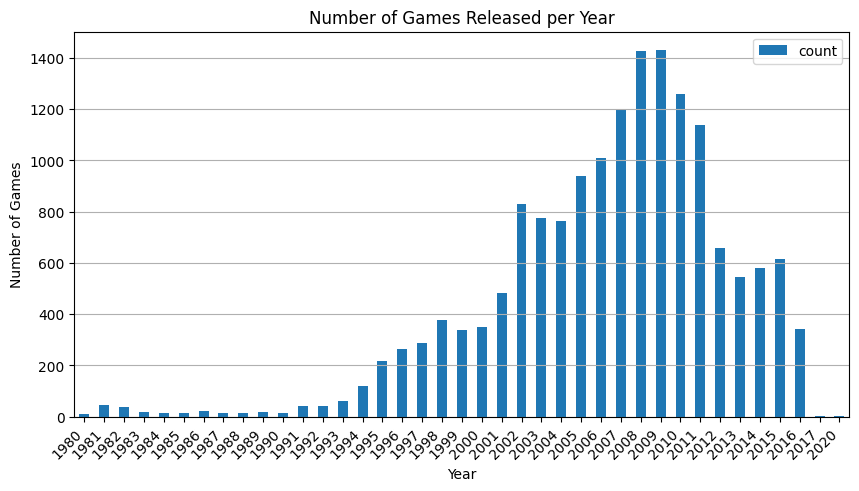

In [37]:
df = videoGameData_df['Year'].value_counts().reset_index().sort_values(by='Year', ignore_index=True)
df['Year'] = df['Year'].astype(int)
#display(df)

df.plot(x='Year', y='count', kind = 'bar', figsize=[10,5])
plt.grid()
plt.xticks(rotation=45, ha='right')
plt.xlabel(xlabel='Year')
plt.ylabel(ylabel='Number of Games')
plt.title('Number of Games Released per Year')
plt.grid(axis='x')
plt.show()


Heatmap for Number of Games per Platform and Genre

Platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
Genre,,,,,,,,,,,,,,,,,,,,,
Action,29.34,NaN,57.02,1.26,115.56,7.92,55.76,37.84,2.74,NaN,...,0.65,NaN,10.08,NaN,NaN,118.58,19.35,242.67,49.28,33.79
Adventure,1.70,0.06,4.81,2.50,47.29,17.16,14.68,5.93,0.19,NaN,...,4.16,NaN,1.50,0.14,NaN,18.43,0.17,15.23,3.06,2.51
Fighting,1.24,NaN,10.46,1.83,7.20,NaN,4.21,18.43,5.90,NaN,...,8.52,NaN,26.95,NaN,NaN,23.86,6.36,37.64,13.55,2.31
Misc,3.58,NaN,10.48,NaN,137.76,13.35,36.25,16.73,0.03,NaN,...,1.20,0.10,5.02,NaN,NaN,221.06,12.23,91.96,9.58,6.86
Platform,13.27,NaN,32.23,2.54,77.45,54.91,78.30,28.66,15.45,0.04,...,0.76,1.50,65.65,NaN,NaN,90.74,21.24,11.39,9.66,0.81
Puzzle,14.68,0.02,5.57,NaN,84.29,47.47,12.92,4.70,NaN,NaN,...,1.00,NaN,6.38,NaN,NaN,15.67,1.33,0.85,0.42,NaN
Racing,2.91,NaN,14.49,2.65,38.64,4.55,18.80,21.89,0.26,NaN,...,2.40,0.07,13.49,NaN,NaN,61.28,7.77,65.99,31.49,8.80
Role-Playing,NaN,NaN,75.74,0.68,126.85,88.24,64.21,13.15,0.27,NaN,...,3.76,0.06,36.43,NaN,1.22,14.06,2.47,71.98,13.51,9.48
Shooter,26.48,NaN,1.29,0.33,8.20,1.20,3.60,13.63,0.13,NaN,...,3.98,NaN,6.07,0.02,NaN,28.77,6.17,278.55,63.55,51.61


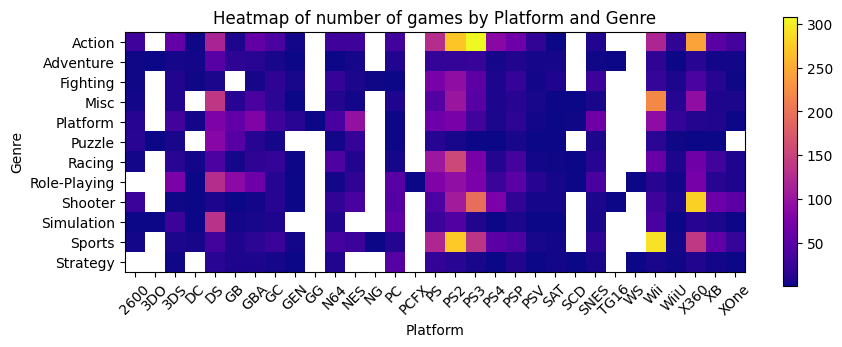

In [87]:
df = videoGameData_df.pivot_table(values='Global_Sales',index='Genre',columns='Platform',aggfunc='sum')

display(df)

#print(df.index)

plt.figure(figsize=(10, 5))
plt.imshow(df, cmap='plasma', interpolation='nearest')
plt.xlabel(xlabel='Platform')
plt.ylabel(ylabel='Genre')
plt.xticks(ticks=range(len(df.columns)), labels=df.columns, rotation = 45)
plt.yticks(ticks=range(len(df.index)), labels=df.index)
plt.colorbar(shrink=0.7) 
plt.title('Heatmap of number of games by Platform and Genre')
plt.show()

Sum of global sales by publisher, mean, and count of number of games.

In [162]:
df = videoGameData_df.groupby('Publisher')['Global_Sales'].agg(['sum', 'mean', 'count']).sort_values(by='count', ascending=False).reset_index()
print("Top 10 Publishers when sorted by number of games (count)")
display(df.head(10))

df = videoGameData_df.groupby('Publisher')['Global_Sales'].agg(['sum', 'mean', 'count']).sort_values(by='mean', ascending=False).reset_index()
print("Top 10 Publishers when sorted by mean")
display(df.head(10))

Top 10 Publishers when sorted by number of games (count)


,Publisher,sum,mean,count
0,Electronic Arts,1110.32,0.821850,1351
1,Activision,727.46,0.746113,975
2,Namco Bandai Games,254.09,0.272629,932
3,Ubisoft,474.72,0.515440,921
4,Konami Digital Entertainment,283.64,0.340913,832
5,THQ,340.77,0.476601,715
6,Nintendo,1786.56,2.541337,703
7,Sony Computer Entertainment,607.50,0.889458,683
8,Sega,272.99,0.427214,639
9,Take-Two Interactive,399.54,0.967409,413


Top 10 Publishers when sorted by mean


,Publisher,sum,mean,count
0,Palcom,4.17,4.170000,1
1,Red Orb,5.24,2.620000,2
2,Nintendo,1786.56,2.541337,703
3,Arena Entertainment,4.72,2.360000,2
4,UEP Systems,2.25,2.250000,1
5,RedOctane,8.68,2.170000,4
6,Valve,1.74,1.740000,1
7,Hello Games,1.60,1.600000,1
8,Sony Computer Entertainment Europe,23.89,1.592667,15
9,Westwood Studios,1.55,1.550000,1


Sum of global sales by platform, mean, and count of number of games.

In [ ]:
df = videoGameData_df.groupby('Platform')['Global_Sales'].agg(['sum', 'mean', 'count']).sort_values(by='count', ascending=False).reset_index()
print("Platforms sorted by number of games (count)")
display(df)

df = videoGameData_df.groupby('Platform')['Global_Sales'].agg(['sum', 'mean', 'count']).sort_values(by='mean', ascending=False).reset_index()
print("Platform sorted by mean")
display(df.head(20))

Platforms sorted by number of games (count)


,Platform,sum,mean,count
0,DS,822.49,0.380254,2163
1,PS2,1255.64,0.581046,2161
2,PS3,957.84,0.720722,1329
3,Wii,926.71,0.699404,1325
4,X360,979.96,0.774672,1265
5,PSP,296.28,0.244254,1213
6,PS,730.66,0.610920,1196
7,PC,258.82,0.269604,960
8,XB,258.26,0.313422,824
9,GBA,318.50,0.387470,822


Platform sorted by mean


,Platform,sum,mean,count
0,GB,255.45,2.606633,98
1,NES,251.07,2.561939,98
2,GEN,28.36,1.050370,27
3,SNES,200.05,0.837029,239
4,PS4,278.10,0.827679,336
5,X360,979.96,0.774672,1265
6,2600,97.08,0.729925,133
7,PS3,957.84,0.720722,1329
8,Wii,926.71,0.699404,1325
9,N64,218.88,0.686144,319


Correlation matrix for global sales

In [ ]:
df = videoGameData_df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr()

display(df)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
NA_Sales,1.000000,0.767727,0.449787,0.634737,0.941047
EU_Sales,0.767727,1.000000,0.435584,0.726385,0.902836
JP_Sales,0.449787,0.435584,1.000000,0.290186,0.611816
Other_Sales,0.634737,0.726385,0.290186,1.000000,0.748331
Global_Sales,0.941047,0.902836,0.611816,0.748331,1.000000


Genre Popularity over the Years

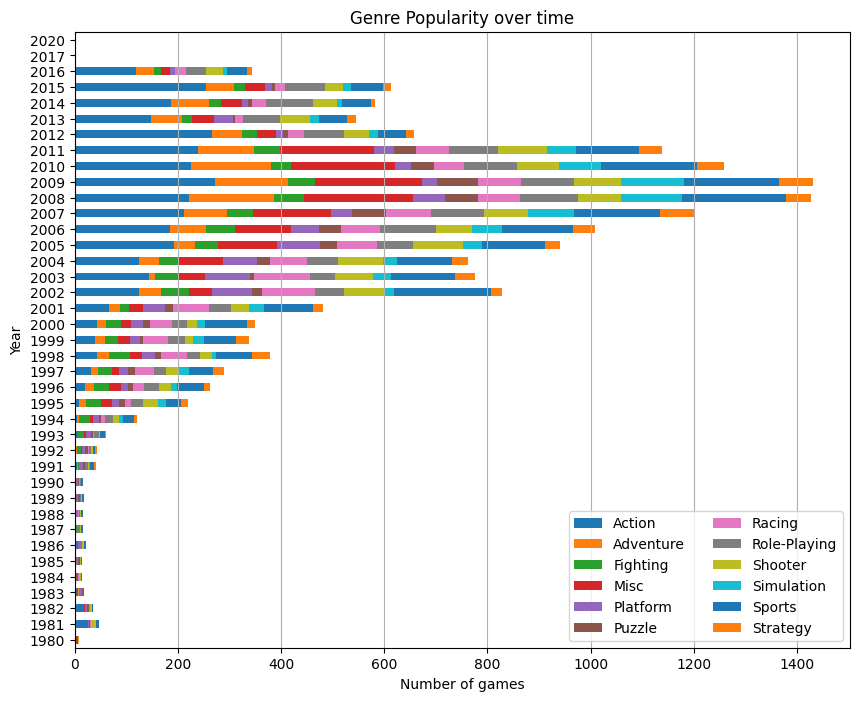

Text(0, 0.5, 'Number of Games in that Genre')

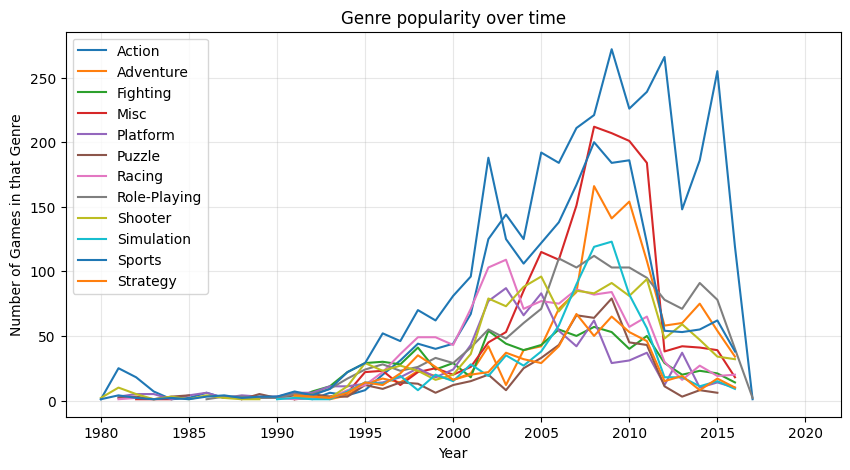

In [206]:
df = videoGameData_df.groupby('Year')['Genre'].value_counts().unstack().reset_index()
df['Year'] = df["Year"].astype(int)
df= df.reset_index(drop=True).set_index('Year')
#display(df)

df.plot(kind='barh', stacked=True, figsize=[10,8])
plt.legend(loc="lower right", ncol=2)
plt.xlabel('Number of games')
plt.ylabel('Year')
plt.title('Genre Popularity over time')
plt.grid(axis='x')
plt.show()


df = videoGameData_df.groupby('Year')['Genre'].value_counts().unstack().reset_index()
df['Year'] = df["Year"].astype(int)
#display(df)

fig, ax = plt.subplots(figsize=(10, 5))
for columnName in df.columns:
    if columnName != 'Year': 
        #print(columnName)
        ax.plot(df['Year'], df[columnName], label=columnName)

ax.legend(loc='upper left')
ax.set_title('Genre popularity over time')
ax.grid(alpha = 0.3)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Games in that Genre')


Platform by publisher

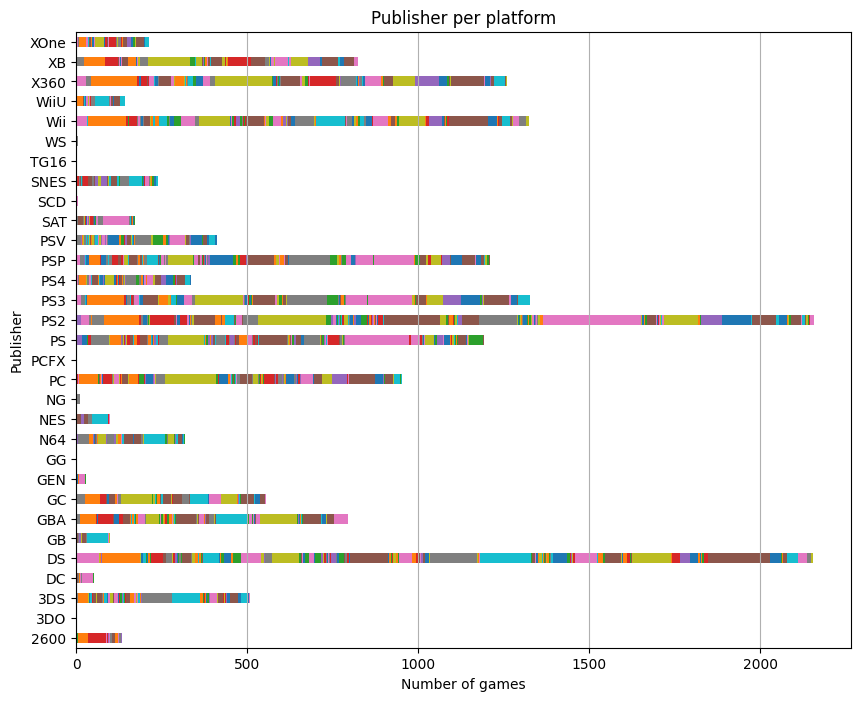

'df = videoGameData_df.groupby(\'Platform\')[\'Publisher\'].unique().unstack()\n#display(df)\n\ndf.plot(kind=\'barh\', stacked=True, figsize=[10,8], legend=False)\n#plt.legend(loc="upper right", ncol=5, fontsize=\'small\')\nplt.xlabel(\'Number of games\')\nplt.ylabel(\'Publisher\')\nplt.title(\'Publisher per platform\')\nplt.grid(axis=\'x\')\nplt.show()'

In [ ]:
df = videoGameData_df.groupby('Platform')['Publisher'].value_counts().unstack()
#display(df)

df.plot(kind='barh', stacked=True, figsize=[10,8], legend=False)
#plt.legend(loc="upper right", ncol=5, fontsize='small')
plt.xlabel('Number of games')
plt.ylabel('Publisher')
plt.title('Publisher per platform')
plt.grid(axis='x')
plt.show()

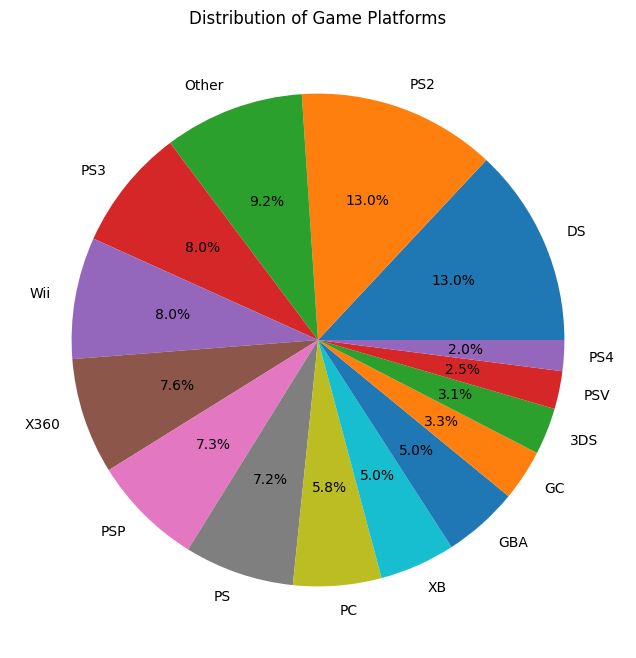

In [21]:
df = videoGameData_df['Platform'].value_counts(normalize=True)*100     #getting the percentages
df = df.reset_index()
#print(df)

indexCounter =0
for number in df['proportion']:
    if number < 2:
        df.at[indexCounter,'Platform'] = 'Other'
        indexCounter = indexCounter+1

    else:
        indexCounter = indexCounter+1

df = df.groupby('Platform').sum().reset_index()
df = df.sort_values(by='proportion', ascending=False)
#print(df)

df.plot(y='proportion', kind='pie', labels=df['Platform'], autopct='%1.1f%%', textprops={'fontsize': 10}, figsize=(12,8), legend=False)
plt.ylabel('')
plt.title('Distribution of Game Platforms')
plt.show()